## Housing Dataset

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor

# as_frame=True returns the 8 features and the target already joined in one DataFrame.
housing = fetch_california_housing(as_frame=True)
housing_df = housing.frame

print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [45]:
house_x = housing_df[housing.feature_names]
house_y = housing_df["MedHouseVal"]
house_x_train, house_x_test, house_y_train, house_y_test = train_test_split(house_x, house_y, test_size=0.2, random_state=42)

In [46]:
# 5 fold Cross validation
from sklearn.model_selection import cross_val_score
all_scores_house = []
for i in range(1,21):
    model = DecisionTreeRegressor(max_depth=i, random_state=42)
    scores = cross_val_score(model, house_x_train, house_y_train, cv=5, scoring="neg_root_mean_squared_error")
    all_scores_house.append(-scores.mean())
    print(f"{i}: CV1: {-scores[0]:.3}, CV2: {-scores[1]:.3}, CV3: {-scores[2]:.3}, CV4: {-scores[3]:.3}, CV5: {-scores[4]:.3}")
    print(f"Mean: {-scores.mean():.3}, Std.: {scores.std():.3}")

1: CV1: 0.962, CV2: 0.94, CV3: 0.962, CV4: 0.955, CV5: 0.968
Mean: 0.957, Std.: 0.00949
2: CV1: 0.869, CV2: 0.841, CV3: 0.867, CV4: 0.856, CV5: 0.863
Mean: 0.859, Std.: 0.0102
3: CV1: 0.808, CV2: 0.775, CV3: 0.792, CV4: 0.795, CV5: 0.808
Mean: 0.796, Std.: 0.0122
4: CV1: 0.769, CV2: 0.734, CV3: 0.749, CV4: 0.758, CV5: 0.768
Mean: 0.755, Std.: 0.0128
5: CV1: 0.738, CV2: 0.701, CV3: 0.7, CV4: 0.717, CV5: 0.708
Mean: 0.713, Std.: 0.0141
6: CV1: 0.706, CV2: 0.679, CV3: 0.664, CV4: 0.673, CV5: 0.662
Mean: 0.677, Std.: 0.0158
7: CV1: 0.677, CV2: 0.651, CV3: 0.651, CV4: 0.639, CV5: 0.646
Mean: 0.653, Std.: 0.0129
8: CV1: 0.663, CV2: 0.644, CV3: 0.635, CV4: 0.622, CV5: 0.619
Mean: 0.637, Std.: 0.0162
9: CV1: 0.66, CV2: 0.636, CV3: 0.615, CV4: 0.627, CV5: 0.626
Mean: 0.633, Std.: 0.0154
10: CV1: 0.655, CV2: 0.645, CV3: 0.629, CV4: 0.643, CV5: 0.642
Mean: 0.643, Std.: 0.00827
11: CV1: 0.686, CV2: 0.657, CV3: 0.639, CV4: 0.658, CV5: 0.639
Mean: 0.656, Std.: 0.0172
12: CV1: 0.684, CV2: 0.673, CV3:

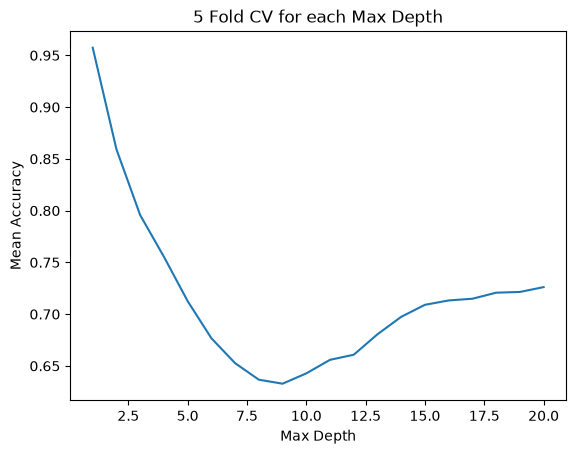

In [47]:
plt.plot(range(1, len(all_scores_house)+1) ,all_scores_house)
plt.xlabel("Max Depth")
plt.ylabel("Mean Accuracy")
plt.title("5 Fold CV for each Max Depth")
plt.show()

In [54]:
dec_tree9 = DecisionTreeRegressor(max_depth=9, random_state=42)
dec_tree9.fit(house_x_train, house_y_train)

test_pred9 = dec_tree9.predict(house_x_test)
acc9 = root_mean_squared_error(house_y_test, test_pred9)
print("RMSE for Decision Tree at Max Depth 9:",acc9)

RMSE for Decision Tree at Max Depth 9: 0.6442578164688181


| | RMSE |
|:-:|:-:|
|5 CV|0.633|
|Test|0.644|

The max depth of 9 was chosen for the Decision Tree as it has the lowest Mean RMSE from the 5 fold Cross Validation. 

I think that the model is generalising predictably, the results are similar to the CV estimate. But with an RMSE of 0.644, it is not really a good model.

## Wine Recognition Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# Load the dataset
wine = load_wine(as_frame=True)

df = wine.frame

# Display the first 5 rows
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [2]:
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 142
Test samples: 36


In [3]:
# Create Logistic Regression model
log_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

# Train the model
log_model.fit(X_train, y_train)

# Make predictions
log_train_pred = log_model.predict(X_train)
log_test_pred = log_model.predict(X_test)

# Calculate accuracy
log_train_acc = accuracy_score(y_train, log_train_pred)
log_test_acc = accuracy_score(y_test, log_test_pred)

print("Logistic Regression")
print("Training Accuracy:", log_train_acc)
print("Test Accuracy:", log_test_acc)

Logistic Regression
Training Accuracy: 1.0
Test Accuracy: 0.9722222222222222


In [4]:
depths = [1, 2, 3, 5, 10, 15]

results = []

# Add Logistic Regression results
results.append({
    "Model": "Logistic Regression",
    "Training Accuracy": log_train_acc,
    "Test Accuracy": log_test_acc
})

# Train Decision Trees with different depths
for depth in depths:

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    # Train the model
    tree.fit(X_train, y_train)

    # Make predictions
    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    # Calculate accuracy
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    # Store results
    results.append({
        "Model": f"Decision Tree (depth={depth})",
        "Training Accuracy": train_acc,
        "Test Accuracy": test_acc
    })

# Display results
results_df = pd.DataFrame(results)

results_df

,Model,Training Accuracy,Test Accuracy
0,Logistic Regression,1.000000,0.972222
1,Decision Tree (depth=1),0.661972,0.583333
2,Decision Tree (depth=2),0.936620,0.861111
3,Decision Tree (depth=3),0.992958,0.944444
4,Decision Tree (depth=5),1.000000,0.944444
5,Decision Tree (depth=10),1.000000,0.944444
6,Decision Tree (depth=15),1.000000,0.944444


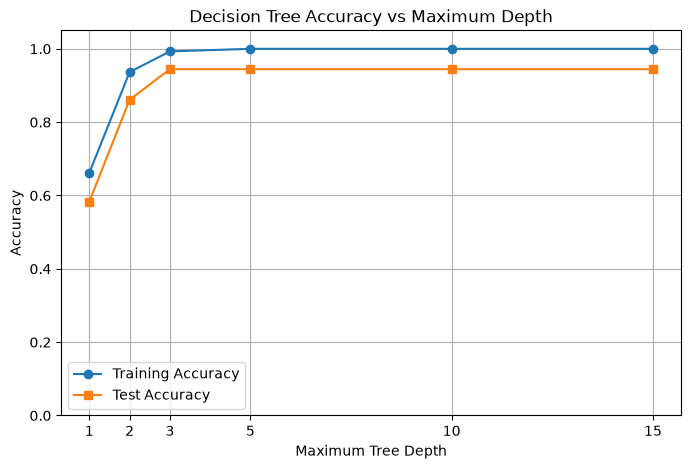

In [5]:
tree_results = results_df.iloc[1:]

plt.figure(figsize=(8, 5))

plt.plot(
    depths,
    tree_results["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depths,
    tree_results["Test Accuracy"],
    marker="s",
    label="Test Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs Maximum Depth")

plt.xticks(depths)
plt.ylim(0, 1.05)

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# 5 fold Cross validation
from sklearn.model_selection import cross_val_score
all_scores_wine = []
for i in range(1,16):
    model = DecisionTreeClassifier(max_depth=i, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=5)
    all_scores_wine.append(scores.mean())
    print(f"{i}: CV1: {scores[0]:.3}, CV2: {scores[1]:.3}, CV3: {scores[2]:.3}, CV4: {scores[3]:.3}, CV5: {scores[4]:.3}")
    print(f"Mean: {scores.mean():.3}, Std.: {scores.std():.3}")

1: CV1: 0.621, CV2: 0.621, CV3: 0.679, CV4: 0.607, CV5: 0.679
Mean: 0.641, Std.: 0.031
2: CV1: 0.828, CV2: 0.862, CV3: 0.929, CV4: 0.893, CV5: 0.964
Mean: 0.895, Std.: 0.0481
3: CV1: 0.862, CV2: 0.897, CV3: 0.929, CV4: 0.929, CV5: 1.0
Mean: 0.923, Std.: 0.0456
4: CV1: 0.862, CV2: 0.862, CV3: 0.929, CV4: 0.929, CV5: 1.0
Mean: 0.916, Std.: 0.0514
5: CV1: 0.862, CV2: 0.862, CV3: 0.929, CV4: 0.929, CV5: 1.0
Mean: 0.916, Std.: 0.0514
6: CV1: 0.862, CV2: 0.862, CV3: 0.929, CV4: 0.929, CV5: 1.0
Mean: 0.916, Std.: 0.0514
7: CV1: 0.862, CV2: 0.862, CV3: 0.929, CV4: 0.929, CV5: 1.0
Mean: 0.916, Std.: 0.0514
8: CV1: 0.862, CV2: 0.862, CV3: 0.929, CV4: 0.929, CV5: 1.0
Mean: 0.916, Std.: 0.0514
9: CV1: 0.862, CV2: 0.862, CV3: 0.929, CV4: 0.929, CV5: 1.0
Mean: 0.916, Std.: 0.0514
10: CV1: 0.862, CV2: 0.862, CV3: 0.929, CV4: 0.929, CV5: 1.0
Mean: 0.916, Std.: 0.0514
11: CV1: 0.862, CV2: 0.862, CV3: 0.929, CV4: 0.929, CV5: 1.0
Mean: 0.916, Std.: 0.0514
12: CV1: 0.862, CV2: 0.862, CV3: 0.929, CV4: 0.92

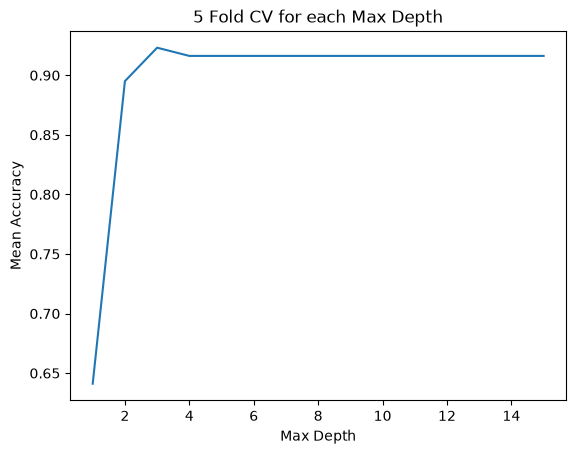

In [ ]:
plt.plot(range(1, len(all_scores_wine)+1) ,all_scores_wine)
plt.xlabel("Max Depth")
plt.ylabel("Mean Accuracy")
plt.title("5 Fold CV for each Max Depth")
plt.show()

In [ ]:
dec_tree3 = DecisionTreeClassifier(max_depth=3, random_state=42)
dec_tree3.fit(X_train, y_train)

test_pred3 = dec_tree3.predict(X_test)
acc3 = accuracy_score(y_test, test_pred3)
print("Accuracy for Decision Tree at Max Depth 3:",acc3)

0.9444444444444444


| | Acc |
|:-:|:-:|
|5 CV|0.923|
|Test|0.944|

Max Depth of 3 was chosen as it has the highest mean accuracy of the 5 fold cross validation. We can also see that the accuracy on the test set reached 1.0 on the last partition of the 5 fold CV from depth 4 onwards. This could be the model overfitting into that specific set of data, also explaining why the mean accuracy is lower.

The model does seem to generalise well and is able to get 94% of the test set.

## Questions